In [1]:
# ---------------------------------------
# 
# read in era5 data and move to aws
# 
# [ *** OUTDATED: check out 
#  `retrieve-data-gcp.ipynb`]
# 
# ---------------------------------------
import os

import dask
import s3fs
import xarray as xr

# --- file destination
dst = 's3://carbonplan-carbon-removal/era5/preprocessed_zarr/'
store_region = 'us'

In [2]:
import zarr
zarr.__version__

'3.1.0'

## Open ERA5 Zarr store on GCP
Learn more [here](https://github.com/google-research/arco-era5). Find it on google's cloud [here](https://console.cloud.google.com/marketplace/product/bigquery-public-data/arco-era5?hl=en-GB&pli=1&inv=1&invt=Ab3emA). 

In [2]:
# --- 
gcp_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/'
ar_full_37_1h = xr.open_zarr(gcp_path, 
                             overwrite_encoded_chunks=True,
                              chunks={'time': 500})

# # [ convert longitude to -180 to 180 ]
# ar_full_37_1h['longitude'] = ((ar_full_37_1h['longitude'] + 180) % 360) - 180
# ar_full_37_1h = ar_full_37_1h.sortby('longitude').chunk({'time': 500, 'latitude': 100, 'longitude': 100})

ar_full_37_1h

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) datetime64[ns] 11MB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
    zero_degree_level                                                (time, latitude, longitude) float32 5TB dask.array<chunksize=(500, 721, 1440), meta=np.ndarray>
Attributes:
    valid_time_start:       1940-01-01
    last_updated:           2025-07-23 01:54:31.932125+00:00
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-17

## Extract selected data 

In [3]:
# -------------------
# RETRY SAVE?
retry = True     # pick up where we left off in building zarr store
# -------------------

# +++++++++++++++++++++++++++++++++++++++++++++++++
# data selection
varlist = ["2m_temperature",
        "skin_reservoir_content",
        "volumetric_soil_water_layer_1",
        "volumetric_soil_water_layer_2",
        "volumetric_soil_water_layer_3",
        "volumetric_soil_water_layer_4",
        "soil_temperature_level_1",
        "soil_temperature_level_2",
        "soil_temperature_level_3",
        "soil_temperature_level_4",
        "potential_evaporation",
        "runoff",
        "surface_runoff",
        "sub_surface_runoff",
        "evaporation",
        "total_precipitation",
        "geopotential",
        "land_sea_mask",
        "soil_type"
        ]
minlat, maxlat = 24, 50
minlon, maxlon = -125, -65
mintime, maxtime = '2000', '2020'
# +++++++++++++++++++++++++++++++++++++++++++++++++

# --- build the store name 
storename = f'{store_region}_{mintime}-{maxtime}.zarr'

# --- select data and explort 
out = ar_full_37_1h[varlist].sel(latitude=slice(maxlat, minlat), 
                                longitude=slice(360+minlon, 360+maxlon),
                                time=slice(mintime, maxtime),
                            ).chunk({'time': 500})
# out = dask.optimize(out)[0]

# if retry:
#     out.to_zarr(os.path.join(dst, storename),
#             consolidated=True,
#             mode='a',              # append instead of overwrite
#             append_dim='time')    # resume appending along time
# else:
#     out.to_zarr(os.path.join(dst, storename), consolidated=True, mode='w')

In [4]:
out

<xarray.Dataset> Size: 1TB
Dimensions:                        (time: 184104, latitude: 105,
                                    longitude: 241, level: 37)
Coordinates:
  * latitude                       (latitude) float32 420B 50.0 49.75 ... 24.0
  * level                          (level) int64 296B 1 2 3 5 ... 950 975 1000
  * longitude                      (longitude) float32 964B 235.0 ... 295.0
  * time                           (time) datetime64[ns] 1MB 2000-01-01 ... 2...
Data variables: (12/19)
    2m_temperature                 (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    skin_reservoir_content         (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    volumetric_soil_water_layer_1  (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    volumetric_soil_water_layer_2  (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    volumetric_soil_water_layer_3  (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    volumetric_soil_water_layer_4  (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    ...                             ...
    sub_surface_runoff             (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    evaporation                    (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    total_precipitation            (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    geopotential                   (time, level, latitude, longitude) float32 689GB dask.array<chunksize=(500, 37, 105, 241), meta=np.ndarray>
    land_sea_mask                  (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
    soil_type                      (time, latitude, longitude) float32 19GB dask.array<chunksize=(500, 105, 241), meta=np.ndarray>
Attributes:
    valid_time_start:       1940-01-01
    last_updated:           2025-07-23 01:54:31.932125+00:00
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-17

In [ ]:
# ---------------------------------

## run some save tests...

In [5]:
# -------------------
# RETRY SAVE?
retry = False     # pick up where we left off in building zarr store
# -------------------
store_region = 'test1'


# +++++++++++++++++++++++++++++++++++++++++++++++++
# data selection
varlist = ["2m_temperature",
        "skin_reservoir_content",
        "volumetric_soil_water_layer_1",
        "volumetric_soil_water_layer_2",
        "volumetric_soil_water_layer_3",
        "volumetric_soil_water_layer_4",
        "soil_temperature_level_1",
        "soil_temperature_level_2",
        "soil_temperature_level_3",
        "soil_temperature_level_4",
        "potential_evaporation",
        "runoff",
        "surface_runoff",
        "sub_surface_runoff",
        "evaporation",
        "total_precipitation",
        "geopotential",
        "land_sea_mask",
        "soil_type"
        ]
minlat, maxlat = 24, 28
minlon, maxlon = -90, -87
mintime, maxtime = '2000', '2002'
# +++++++++++++++++++++++++++++++++++++++++++++++++

# --- build the store name 
storename = f'{store_region}_{mintime}-{maxtime}.zarr'

# --- select data and explort 
out = ar_full_37_1h[varlist].sel(latitude=slice(maxlat, minlat), 
                                longitude=slice(360+minlon, 360+maxlon),
                                time=slice(mintime, maxtime),
                            ).chunk({'time': 100})
# # Remove incompatible chunk encodings
# for var in out.data_vars:
#     out[var].encoding.pop('chunks', None)

# out = dask.optimize(out)[0]

# if retry:
#     out.to_zarr(os.path.join(dst, storename),
#             consolidated=True,
#             mode='a',              # append instead of overwrite
#             append_dim='time')    # resume appending along time
# else:
#     out.to_zarr(os.path.join(dst, storename), consolidated=True, mode='w')

In [11]:
import dask

out_size_bytes = dask.utils.format_bytes(out.nbytes)
print(f"Estimated dataset size: {out_size_bytes}")


Estimated dataset size: 1.19 GiB


In [12]:
dsx = out.load()

: 

In [ ]:
dsx

NameError: name 'plt' is not defined

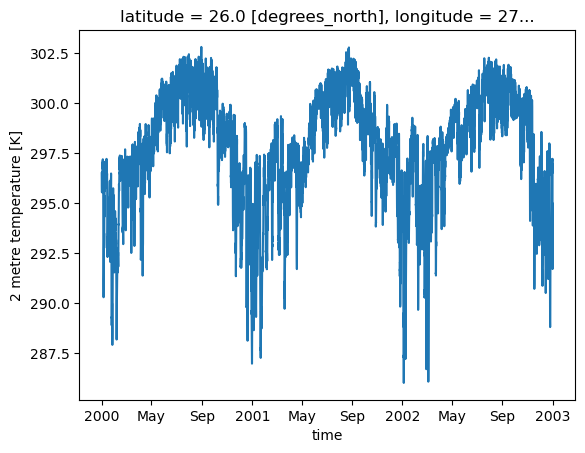

In [10]:
ts = out['2m_temperature'].sel(latitude=26, longitude=360-88.5, method='nearest')
ts.plot()
plt.title('2m Temperature Time Series')
plt.show()

In [ ]:
# ---------------------------------

In [4]:
# -------------------
# RETRY SAVE?
retry = True     # pick up where we left off in building zarr store
# -------------------

# +++++++++++++++++++++++++++++++++++++++++++++++++
# data selection
varlist = ["2m_temperature",
        ]
minlat, maxlat = 35, 38
minlon, maxlon = -113, -107
mintime, maxtime = '1940', '1950'
# +++++++++++++++++++++++++++++++++++++++++++++++++

# --- build the store name 
# storename = f'{store_region}_{mintime}-{maxtime}.zarr'

# --- select data and explort 
out = ar_full_37_1h[varlist].sel(latitude=slice(maxlat, minlat), 
                                longitude=slice(360+minlon, 360+maxlon),
                                time=slice(mintime, maxtime),
                            ).chunk({'time': 500})
out = dask.optimize(out)[0]
out#.mean(['latitude', 'longitude', 'time'])

# if retry:
#     out.to_zarr(os.path.join(dst, storename),
#             consolidated=True,
#             mode='a',              # append instead of overwrite
#             append_dim='time')    # resume appending along time
# else:
#     out.to_zarr(os.path.join(dst, storename), consolidated=True, mode='w')

<xarray.Dataset> Size: 126MB
Dimensions:         (time: 96432, latitude: 13, longitude: 25)
Coordinates:
  * latitude        (latitude) float32 52B 38.0 37.75 37.5 ... 35.5 35.25 35.0
  * longitude       (longitude) float32 100B 247.0 247.2 247.5 ... 252.8 253.0
  * time            (time) datetime64[ns] 771kB 1940-01-01 ... 1950-12-31T23:...
Data variables:
    2m_temperature  (time, latitude, longitude) float32 125MB dask.array<chunksize=(500, 13, 25), meta=np.ndarray>
Attributes:
    valid_time_start:       1940-01-01
    last_updated:           2025-07-23 01:54:31.932125+00:00
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-17

In [11]:
out['2m_temperature'].mean(['time','latitude']).values()

TypeError: 'numpy.ndarray' object is not callable